<a href="https://colab.research.google.com/github/llayan-1/typiclust-cw2/blob/main/typiclust_cw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Coursework 2

**Name:** Layan Alsubhi

**Student Number:** K23065725

**Module:** 5CCSAMLF Machine Learning

**Code Repository:** The full implementation is available at the following GitHub repository: [GitHub Repository Link](https://github.com/llayan-1/typiclust-cw2.git)

## What is TPC_RP?

TPC_RP is an active learning strategy designed for low-label settings,
where only a small number of samples can be annotated. Instead of relying
on uncertainty-based selection, it focuses on selecting typical samples
that lie in dense regions of the feature space and better represent the
overall data distribution.

In very low-label scenarios, uncertainty estimates from neural networks
are often unreliable due to overfitting. For this reason, selecting
representative samples provides a more stable starting point for training.

The implementation follows three steps:
1. Train a SimCLR encoder to learn feature representations without labels  
2. Cluster the unlabeled data using K-means  
3. Select the most typical sample from each cluster, based on its distance
   to neighbouring points in the embedding space  

# Pipeline
 1. Train SimCLR encoder
 2. Extract embeddings
 3. Cluster embeddings
 4. Select samples using typicality
 5. Train classifier and evaluate

## Setup
Imports, seeds, and device configuration.

In [ ]:
import random
import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42 # Fixed for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [ ]:
# Normalisation values for CIFAR-10 dataset
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

## Data Loading
Loading CIFAR-10 for SimCLR training and supervised evaluation.

In [ ]:
# Augmentations for SimCLR - applies two different random views of each image
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# No augmentation for evaluation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [ ]:
# Wraps the dataset to return two augmented views per sample
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]
        view1 = self.transform(image)
        view2 = self.transform(image)
        return view1, view2, idx

In [ ]:
# Unlabelled training data used for SimCLR representation learning
train_base = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=None
)

# Test set for final supervised evaluation
test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Single-view normalised train set for evaluation classifier
train_eval_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)

print("Train size:", len(train_base))
print("Test size:", len(test_set))

100%|██████████| 170M/170M [00:09<00:00, 17.5MB/s]


Train size: 50000
Test size: 10000


In [ ]:
simclr_dataset = SimCLRDataset(train_base, simclr_transform)

# DataLoader for contrastive training
simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

print("SimCLR batches:", len(simclr_loader))

SimCLR batches: 97


## SimCLR Training
Training the self-supervised encoder to learn useful feature representations.

In [ ]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)

        # Modify ResNet18 for CIFAR-10 (smaller images, no initial downsampling)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()

        # Remove final classification layer to use as feature extractor
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = backbone.fc.in_features

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

In [ ]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = ResNet18Encoder()

        # Projection head used in SimCLR to map features into contrastive space
        self.projector = nn.Sequential(
            nn.Linear(self.encoder.feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)
        # L2 normalisation improves contrastive learning stability
        projections = F.normalize(projections, dim=1)
        return features, projections

In [ ]:
# NT-Xent loss used in SimCLR: brings augmented views of the same image closer,
# while pushing apart representations of different images
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)

        z = torch.cat([z1, z2], dim=0)

        # Compute similarity matrix between all pairs in the batch
        sim = torch.matmul(z, z.T) / self.temperature

        # Remove self-similarity (diagonal)
        mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
        sim.masked_fill_(mask, -9e15)



        labels = torch.cat([torch.arange(batch_size, 2 * batch_size, device=z.device),
            torch.arange(0, batch_size, device=z.device)])

        # Denominator includes all except self
        loss = F.cross_entropy(sim, labels)
        return loss

In [ ]:
def train_simclr(model, loader, epochs=50, lr=0.4):
    criterion = NTXentLoss(temperature=0.5)
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=1e-4,
        nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        # Each batch contains two augmented views of the same images
        for x1, x2, _ in loader:
            x1 = x1.to(device)
            x2 = x2.to(device)

            _, z1 = model(x1)
            _, z2 = model(x2)

            # Compute contrastive loss between paired representations
            loss = criterion(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(loader)
        print(f"SimCLR Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

In [ ]:
simclr_model = SimCLRModel(projection_dim=128).to(device)
train_simclr(simclr_model, simclr_loader, epochs=50, lr=0.4)

SimCLR Epoch 1/50, Loss: 6.2803
SimCLR Epoch 2/50, Loss: 5.9215
SimCLR Epoch 3/50, Loss: 5.7624
SimCLR Epoch 4/50, Loss: 5.6694
SimCLR Epoch 5/50, Loss: 5.6162
SimCLR Epoch 6/50, Loss: 5.5636
SimCLR Epoch 7/50, Loss: 5.5255
SimCLR Epoch 8/50, Loss: 5.4965
SimCLR Epoch 9/50, Loss: 5.4703
SimCLR Epoch 10/50, Loss: 5.4516
SimCLR Epoch 11/50, Loss: 5.4356
SimCLR Epoch 12/50, Loss: 5.4193
SimCLR Epoch 13/50, Loss: 5.4099
SimCLR Epoch 14/50, Loss: 5.4003
SimCLR Epoch 15/50, Loss: 5.3920
SimCLR Epoch 16/50, Loss: 5.3851
SimCLR Epoch 17/50, Loss: 5.3775
SimCLR Epoch 18/50, Loss: 5.3684
SimCLR Epoch 19/50, Loss: 5.3619
SimCLR Epoch 20/50, Loss: 5.3567
SimCLR Epoch 21/50, Loss: 5.3524
SimCLR Epoch 22/50, Loss: 5.3471
SimCLR Epoch 23/50, Loss: 5.3443
SimCLR Epoch 24/50, Loss: 5.3364
SimCLR Epoch 25/50, Loss: 5.3312
SimCLR Epoch 26/50, Loss: 5.3254
SimCLR Epoch 27/50, Loss: 5.3236
SimCLR Epoch 28/50, Loss: 5.3179
SimCLR Epoch 29/50, Loss: 5.3136
SimCLR Epoch 30/50, Loss: 5.3087
SimCLR Epoch 31/50,

## Feature Extraction
Extracting and L2-normalising embeddings from the trained encoder.

In [ ]:
# DataLoader used to extract features without shuffling
feature_loader = DataLoader(
    train_eval_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

In [ ]:
# Extract features and normalise them for similarity-based operations
def extract_all_embeddings(encoder_model, loader):
    encoder_model.eval()
    all_embeddings = []

    # Disable gradients for faster inference
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            # Extract features and normalise them for similarity-based operations
            embeddings = F.normalize(encoder_model.encoder(images), dim=1)
            all_embeddings.append(embeddings.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    return all_embeddings.numpy()

all_train_embeddings = extract_all_embeddings(simclr_model, feature_loader)
print("Embeddings ready for clustering: ", all_train_embeddings.shape)

Embeddings ready for clustering:  (50000, 512)


## Clustering and Selection
In this stage, the SimCLR embeddings are clustered and typicality is computed
within each cluster. The algorithm then selects one representative sample from
the most informative uncovered clusters, following the TPC_RP selection logic.

In [ ]:
# Compute typicality inside a cluster using inverse average distance
def compute_typicality_scores(cluster_embeddings, k=20):
    if len(cluster_embeddings) == 1:
        return np.array([1.0], dtype=np.float32)

    # Use at most cluster_size - 1 neighbours
    k_use = min(k, len(cluster_embeddings) - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)

    # Skip first neighbour (itself), average the rest
    avg_distances = distances[:, 1:].mean(axis=1)

    # Higher score = closer to neighbours = more typical
    typicality_scores = 1.0 / (avg_distances + 1e-8)

    return typicality_scores

In [ ]:
# Select a batch of samples using TPC_RP
def typiclust_select_batch(
    all_embeddings,
    labelled_indices,
    unlabelled_indices,
    budget=10,
    max_clusters=500,
    typicality_k=20
):
    labelled_indices = list(labelled_indices)
    unlabelled_indices = list(unlabelled_indices)

    if len(unlabelled_indices) == 0:
        return []

    # Number of clusters
    num_clusters = min(len(labelled_indices) + budget, max_clusters, len(unlabelled_indices))

    unlabelled_embeddings = all_embeddings[unlabelled_indices]

    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters,
        random_state=SEED,
        batch_size=1024,
        n_init=10
    )
    unlabelled_cluster_labels = kmeans.fit_predict(unlabelled_embeddings)

    # Count how many labelled samples are already associated with each cluster
    labelled_cluster_counts = np.zeros(num_clusters, dtype=int)
    if len(labelled_indices) > 0:
        labelled_embeddings = all_embeddings[labelled_indices]
        distances_to_centers = np.linalg.norm(
            labelled_embeddings[:, None, :] - kmeans.cluster_centers_[None, :, :],
            axis=2
        )
        labelled_cluster_ids = distances_to_centers.argmin(axis=1)

        for cid in labelled_cluster_ids:
            labelled_cluster_counts[cid] += 1

    cluster_to_unlabelled_positions = defaultdict(list)
    for pos, cid in enumerate(unlabelled_cluster_labels):
        cluster_to_unlabelled_positions[cid].append(pos)

    # Store cluster information used in the selection step
    # Ignore very small clusters, since typicality is less reliable below 5 points
    cluster_info = []
    for cid, positions in cluster_to_unlabelled_positions.items():
        if len(positions) >= 5:
            cluster_info.append({
                "cluster_id": cid,
                "labelled_count": labelled_cluster_counts[cid],
                "size": len(positions),
                "positions": positions
            })

    selected_positions = []
    used_clusters = set()

    while len(selected_positions) < budget and len(used_clusters) < len(cluster_info):
        remaining = [c for c in cluster_info if c["cluster_id"] not in used_clusters]
        if not remaining:
            break

        min_labelled = min(c["labelled_count"] for c in remaining)
        candidates = [c for c in remaining if c["labelled_count"] == min_labelled]

        # Among fewest-labelled clusters, prefer the largest
        candidates.sort(key=lambda x: x["size"], reverse=True)
        chosen_cluster = candidates[0]

        cid = chosen_cluster["cluster_id"]
        positions = chosen_cluster["positions"]
        cluster_embeddings = unlabelled_embeddings[positions]

        # Choose the most representative point within the selected cluster
        typicality_scores = compute_typicality_scores(cluster_embeddings, k=typicality_k)
        best_local_idx = np.argmax(typicality_scores)
        best_pos = positions[best_local_idx]

        selected_positions.append(best_pos)
        used_clusters.add(cid)


    if len(selected_positions) < budget:
        print(f"Warning: only selected {len(selected_positions)} of {budget} requested.")

    selected_dataset_indices = [unlabelled_indices[pos] for pos in selected_positions]
    return selected_dataset_indices

## Evaluation
At each active learning round, a classifier is trained from scratch on the
currently labelled dataset. Test accuracy is then measured to evaluate how
the selected samples improve model performance over time.

In [ ]:
# Train a supervised classifier on the current labelled dataset
def train_eval_model(model, loader, epochs=50, lr=0.025):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        nesterov=True,
        weight_decay=5e-4
        )
    # Cosine schedule decays lr smoothly to zero
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass and los
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(loader)
        print(f"Eval Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

In [ ]:
# Evaluate model accuracy on the test set
def evaluate_model(model, loader):
    model.eval() # Disables dropout and batchnorm training behaviour
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100.0 * correct / total

In [ ]:
# Fixed test loader used consistently across all rounds
test_loader = DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

The model is retrained from scratch at each round to ensure that performance
reflects only the quality of the selected samples, rather than accumulated training.

In [ ]:
# Same CIFAR-adapted ResNet18 as encoder but with classification head
class EvalResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                                    stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        backbone.fc = nn.Linear(512, num_classes)
        self.model = backbone

    def forward(self, x):
        return self.model(x)


train_transform_supervised = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Loads only the selected labelled indices with training augmentation
class LabeledSubset(Dataset):
    def __init__(self, indices, transform):
        self.base = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=False, transform=None)
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]
        return self.transform(img), label


def active_learning_round_tpcrp(
    all_embeddings,
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Select new samples using TPC_RP strategy
    newly_selected = typiclust_select_batch(
        all_embeddings=all_embeddings,
        labelled_indices=labelled_indices,
        unlabelled_indices=unlabelled_indices,
        budget=budget,
        max_clusters=500,
        typicality_k=20
    )

    # Update pools
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [idx for idx in unlabelled_indices if idx not in selected_set]

    # Build labelled subset with training augmentation
    labelled_subset = LabeledSubset(labelled_indices, transform=train_transform_supervised)
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    # Reinitialise model each round to avoid bias from previous training
    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader, epochs=eval_epochs, lr=0.025)

    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

## Results
Running the active learning loop and plotting accuracy over rounds.

In [ ]:
# Cold start: L_0 = empty, no labelled data
labelled_indices_tpcrp = []
unlabelled_indices_tpcrp = list(range(len(train_base)))  # All 50,000 images

all_train_labels = np.array(train_base.targets)

print("Initial labelled  :", len(labelled_indices_tpcrp))
print("Initial unlabelled:", len(unlabelled_indices_tpcrp))

Initial labelled  : 0
Initial unlabelled: 50000


In [ ]:
# Small budget per round to simulate low-label active learning
budget_per_round = 10
num_rounds = 5 # 5 rounds = 50 total labelled samples

results = []

# Run active learning for multiple rounds and track performance
for round_num in range(num_rounds):
    print(f"\n===== Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_tpcrp, unlabelled_indices_tpcrp, acc = active_learning_round_tpcrp(
        all_embeddings=all_train_embeddings,
        labelled_indices=labelled_indices_tpcrp,
        unlabelled_indices=unlabelled_indices_tpcrp,
        budget=budget_per_round,
        eval_batch_size=128,
        eval_epochs=50
    )

    class_counts = np.bincount(all_train_labels[labelled_indices_tpcrp], minlength=10)
    print(f"Labelled    : {len(labelled_indices_tpcrp)}")
    print(f"Unlabelled  : {len(unlabelled_indices_tpcrp)}")
    print(f"Class dist  : {class_counts.tolist()}")
    # Accuracy reflects how useful the selected samples were
    print(f"Test Accuracy: {acc:.2f}%")

    results.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_tpcrp),
        "accuracy": acc
    })


===== Round 1/5 =====
Eval Epoch 1/50, Loss: 2.6956
Eval Epoch 2/50, Loss: 1.7516
Eval Epoch 3/50, Loss: 1.7221
Eval Epoch 4/50, Loss: 1.7903
Eval Epoch 5/50, Loss: 1.9216
Eval Epoch 6/50, Loss: 1.4327
Eval Epoch 7/50, Loss: 1.2463
Eval Epoch 8/50, Loss: 1.1101
Eval Epoch 9/50, Loss: 1.3726
Eval Epoch 10/50, Loss: 0.8962
Eval Epoch 11/50, Loss: 0.3242
Eval Epoch 12/50, Loss: 0.1315
Eval Epoch 13/50, Loss: 0.1585
Eval Epoch 14/50, Loss: 0.1312
Eval Epoch 15/50, Loss: 0.0769
Eval Epoch 16/50, Loss: 0.0618
Eval Epoch 17/50, Loss: 0.0463
Eval Epoch 18/50, Loss: 0.0382
Eval Epoch 19/50, Loss: 0.0106
Eval Epoch 20/50, Loss: 0.0194
Eval Epoch 21/50, Loss: 0.0048
Eval Epoch 22/50, Loss: 0.0190
Eval Epoch 23/50, Loss: 0.0037
Eval Epoch 24/50, Loss: 0.0101
Eval Epoch 25/50, Loss: 0.0030
Eval Epoch 26/50, Loss: 0.0052
Eval Epoch 27/50, Loss: 0.0011
Eval Epoch 28/50, Loss: 0.0023
Eval Epoch 29/50, Loss: 0.0036
Eval Epoch 30/50, Loss: 0.0034
Eval Epoch 31/50, Loss: 0.0042
Eval Epoch 32/50, Loss: 0

In [ ]:
# quick summary before plotting
for row in results:
    print(f"Round {row['round']}: labelled={row['labelled']}, accuracy={row['accuracy']:.2f}%")

Round 1: labelled=10, accuracy=17.51%
Round 2: labelled=20, accuracy=17.44%
Round 3: labelled=30, accuracy=21.21%
Round 4: labelled=40, accuracy=25.00%
Round 5: labelled=50, accuracy=25.76%


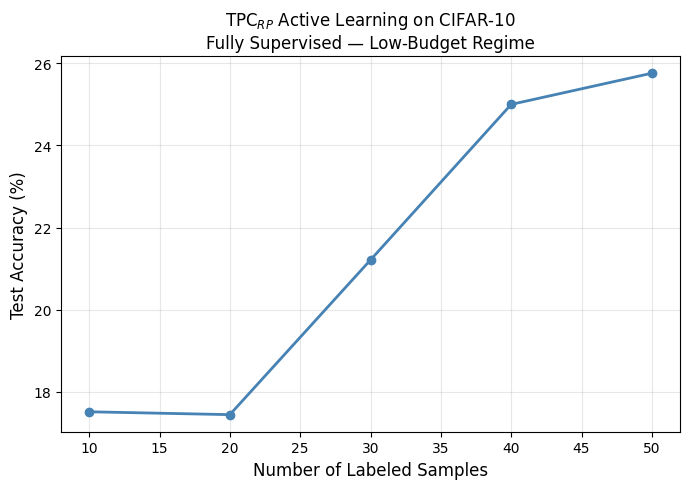

In [ ]:
labelled_counts = [r["labelled"] for r in results]
accuracies = [r["accuracy"] for r in results]

plt.figure(figsize=(7, 5))
plt.plot(labelled_counts, accuracies, marker="o", linewidth=2, color="steelblue")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ Active Learning on CIFAR-10\nFully Supervised — Low-Budget Regime", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Random Baseline
Selects samples uniformly at random — no embeddings needed Used as a lower-bound comparison for TPCRP evaluation.


In [ ]:
# Random Sampling Baseline
# Selects samples uniformly at random
# Used as a lower-bound comparison for TPCRP
def random_select_batch(unlabelled_indices, budget):
    # Randomly sample from unlabelled pool - no typicality required
    budget = min(budget, len(unlabelled_indices))
    return random.sample(list(unlabelled_indices), budget)

def active_learning_round_random(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Select new samples randomly
    newly_selected = random_select_batch(unlabelled_indices, budget)

    # Update pools — same pattern as active_learning_round_tpcrp
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices if idx not in selected_set
    ]

    # Build labelled subset with training augmentation
    labelled_subset = LabeledSubset(
        labelled_indices, transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    # Retrain from scratch each round for fair comparison
    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

In [ ]:
# Cold start same initial conditions as TPCRP
labelled_indices_random = []
unlabelled_indices_random = list(range(len(train_base)))

print("Initial labelled :", len(labelled_indices_random))
print("Initial unlabelled:", len(unlabelled_indices_random))

budget_per_round = 10
num_rounds = 5
results_random = []

for round_num in range(num_rounds):
    print(f"\n===== Random Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_random, unlabelled_indices_random, acc = \
        active_learning_round_random(
            labelled_indices=labelled_indices_random,
            unlabelled_indices=unlabelled_indices_random,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_random], minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_random)}")
    print(f"Unlabelled : {len(unlabelled_indices_random)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_random.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_random),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Random Round 1/5 =====
Eval Epoch 1/50, Loss: 2.4686
Eval Epoch 2/50, Loss: 2.9495
Eval Epoch 3/50, Loss: 2.5870
Eval Epoch 4/50, Loss: 1.1510
Eval Epoch 5/50, Loss: 1.2045
Eval Epoch 6/50, Loss: 0.8626
Eval Epoch 7/50, Loss: 0.6590
Eval Epoch 8/50, Loss: 0.4429
Eval Epoch 9/50, Loss: 0.3041
Eval Epoch 10/50, Loss: 0.2164
Eval Epoch 11/50, Loss: 0.1192
Eval Epoch 12/50, Loss: 0.0885
Eval Epoch 13/50, Loss: 0.0472
Eval Epoch 14/50, Loss: 0.0613
Eval Epoch 15/50, Loss: 0.0297
Eval Epoch 16/50, Loss: 0.0221
Eval Epoch 17/50, Loss: 0.0181
Eval Epoch 18/50, Loss: 0.0066
Eval Epoch 19/50, Loss: 0.0052
Eval Epoch 20/50, Loss: 0.0058
Eval Epoch 21/50, Loss: 0.0057
Eval Epoch 22/50, Loss: 0.0070
Eval Epoch 23/50, Loss: 0.0047
Eval Epoch 24/50, Loss: 0.0025
Eval Epoch 25/50, Loss: 0.0013
Eval Epoch 26/50, Loss: 0.0018
Eval Epoch 27/50, Loss: 0.0032
Eval Epoch 28/50, Loss: 0.0014
Eval Epoch 29/50, Loss: 0.0032
Eval Epoch 30/50, Loss: 0.0013
Ev

In [ ]:
# Compare TPCRP against random baseline across rounds
print("Accuracy comparison: TPCRP vs Random\n")
for i in range(5):
    tpcrp_acc = results[i]['accuracy']
    rand_acc  = results_random[i]['accuracy']
    gap       = tpcrp_acc - rand_acc
    print(f"Round {i+1} ({results[i]['labelled']} labels): "
          f"TPCRP = {tpcrp_acc:.2f}% | "
          f"Random = {rand_acc:.2f}% | "
          f"Gap = +{gap:.2f} pp")

Accuracy comparison: TPCRP vs Random

Round 1 (10 labels): TPCRP = 17.51% | Random = 15.35% | Gap = +2.16 pp
Round 2 (20 labels): TPCRP = 17.44% | Random = 19.78% | Gap = +-2.34 pp
Round 3 (30 labels): TPCRP = 21.21% | Random = 18.27% | Gap = +2.94 pp
Round 4 (40 labels): TPCRP = 25.00% | Random = 21.48% | Gap = +3.52 pp
Round 5 (50 labels): TPCRP = 25.76% | Random = 23.28% | Gap = +2.48 pp


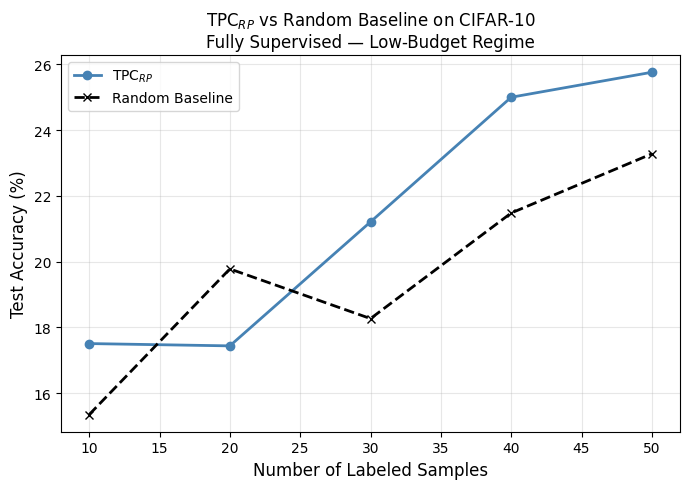

In [ ]:
# Updated plot: TPCRP vs Random Baseline
labelled_counts  = [r["labelled"]  for r in results]
accuracies       = [r["accuracy"]  for r in results]
random_counts    = [r["labelled"]  for r in results_random]
random_accs      = [r["accuracy"]  for r in results_random]

plt.figure(figsize=(7, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random Baseline")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Random Baseline on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_random.png", dpi=150, bbox_inches="tight")
plt.show()

# Uncertainty Sampling Baseline
Selects samples the current classifier is least confident about. Expected to underperform random at low budgets (cold start problem) — confirming the paper's central claim.


In [ ]:
# Least-Confidence (Uncertainty) Sampling Baseline
# Selects samples where the model has lowest confidence.
# Typically performs poorly early due to cold start.

def uncertainty_select_batch(
    current_model,
    unlabelled_indices,
    budget=10
):
    # Budget protection
    budget = min(budget, len(unlabelled_indices))

    current_model.eval()

    unlabelled_subset = LabeledSubset(
        unlabelled_indices,
        transform=test_transform
    )
    unlabelled_loader = DataLoader(
        unlabelled_subset,
        batch_size=256,
        shuffle=False,
        num_workers=2
    )

    all_max_probs = []

    with torch.no_grad():
        for images, _ in unlabelled_loader:
            images = images.to(device)
            outputs = current_model(images)
            probs = torch.softmax(outputs, dim=1)
            # Highest probability = most confident
            max_probs = probs.max(dim=1).values
            all_max_probs.append(max_probs.cpu())

    all_max_probs = torch.cat(all_max_probs, dim=0)

    # Select LEAST confident = lowest max probability
    _, uncertain_positions = torch.topk(
        all_max_probs, budget, largest=False
    )

    return [unlabelled_indices[i] for i in
            uncertain_positions.tolist()]


def active_learning_round_uncertainty(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Cold start: fall back to random if no labelled data yet
    if len(labelled_indices) == 0:
        newly_selected = random.sample(
            list(unlabelled_indices),
            min(budget, len(unlabelled_indices))
        )
    else:
        # Train query model on current labelled set
        labelled_subset = LabeledSubset(
            labelled_indices,
            transform=train_transform_supervised
        )
        labelled_loader = DataLoader(
            labelled_subset,
            batch_size=eval_batch_size,
            shuffle=True,
            num_workers=2
        )
        query_model = EvalResNet18(num_classes=10).to(device)
        train_eval_model(query_model, labelled_loader,
                         epochs=eval_epochs, lr=0.025)

        # Select least confident samples
        newly_selected = uncertainty_select_batch(
            query_model, unlabelled_indices, budget
        )

    # Update pools (same structure as other baselines)
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices
        if idx not in selected_set
    ]

    # Retrain model on updated labelled set and evaluate
    labelled_subset = LabeledSubset(
        labelled_indices,
        transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

print("Uncertainty functions defined.")

Uncertainty functions defined.


In [ ]:
# Cold start: same setup as TPCRP and Random
labelled_indices_uncertainty = []
unlabelled_indices_uncertainty = list(range(len(train_base)))

print("Initial labelled :", len(labelled_indices_uncertainty))
print("Initial unlabelled:", len(unlabelled_indices_uncertainty))

results_uncertainty = []

# Run uncertainty sampling for multiple rounds
for round_num in range(num_rounds):
    print(f"\n===== Uncertainty Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_uncertainty, \
    unlabelled_indices_uncertainty, acc = \
        active_learning_round_uncertainty(
            labelled_indices=labelled_indices_uncertainty,
            unlabelled_indices=unlabelled_indices_uncertainty,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_uncertainty],
        minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_uncertainty)}")
    print(f"Unlabelled : {len(unlabelled_indices_uncertainty)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_uncertainty.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_uncertainty),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Uncertainty Round 1/5 =====
Eval Epoch 1/50, Loss: 2.3133
Eval Epoch 2/50, Loss: 1.7919
Eval Epoch 3/50, Loss: 1.5052
Eval Epoch 4/50, Loss: 1.4012
Eval Epoch 5/50, Loss: 1.0111
Eval Epoch 6/50, Loss: 0.7565
Eval Epoch 7/50, Loss: 0.5606
Eval Epoch 8/50, Loss: 0.3298
Eval Epoch 9/50, Loss: 0.1776
Eval Epoch 10/50, Loss: 0.0988
Eval Epoch 11/50, Loss: 0.0574
Eval Epoch 12/50, Loss: 0.0251
Eval Epoch 13/50, Loss: 0.0167
Eval Epoch 14/50, Loss: 0.0157
Eval Epoch 15/50, Loss: 0.0560
Eval Epoch 16/50, Loss: 0.0068
Eval Epoch 17/50, Loss: 0.0073
Eval Epoch 18/50, Loss: 0.0043
Eval Epoch 19/50, Loss: 0.0170
Eval Epoch 20/50, Loss: 0.0062
Eval Epoch 21/50, Loss: 0.0029
Eval Epoch 22/50, Loss: 0.0017
Eval Epoch 23/50, Loss: 0.0009
Eval Epoch 24/50, Loss: 0.0029
Eval Epoch 25/50, Loss: 0.0011
Eval Epoch 26/50, Loss: 0.0012
Eval Epoch 27/50, Loss: 0.0012
Eval Epoch 28/50, Loss: 0.0011
Eval Epoch 29/50, Loss: 0.0053
Eval Epoch 30/50, Loss: 0.00

In [ ]:
# Compare TPCRP, Random, and Least-Confidence
print("Accuracy comparison: TPCRP vs Random vs Least-Confidence\n")

for i in range(5):
    tpcrp_acc = results[i]['accuracy']
    rand_acc  = results_random[i]['accuracy']
    unc_acc   = results_uncertainty[i]['accuracy']

    print(f"Round {i+1} ({results[i]['labelled']} labels): "
          f"TPCRP = {tpcrp_acc:.2f}% | "
          f"Random = {rand_acc:.2f}% | "
          f"Least-Conf = {unc_acc:.2f}%")

Accuracy comparison: TPCRP vs Random vs Least-Confidence

Round 1 (10 labels): TPCRP = 17.51% | Random = 15.35% | Least-Conf = 17.46%
Round 2 (20 labels): TPCRP = 17.44% | Random = 19.78% | Least-Conf = 18.53%
Round 3 (30 labels): TPCRP = 21.21% | Random = 18.27% | Least-Conf = 21.41%
Round 4 (40 labels): TPCRP = 25.00% | Random = 21.48% | Least-Conf = 21.70%
Round 5 (50 labels): TPCRP = 25.76% | Random = 23.28% | Least-Conf = 20.58%


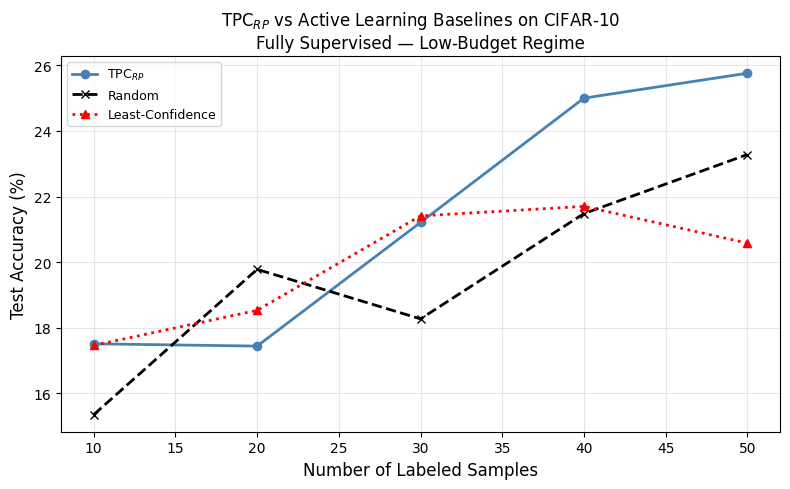

In [ ]:
# Plot TPCRP vs active learning baselines
uncertainty_counts = [r["labelled"] for r in results_uncertainty]
uncertainty_accs   = [r["accuracy"] for r in results_uncertainty]

plt.figure(figsize=(8, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random")
plt.plot(uncertainty_counts, uncertainty_accs,
         marker="^", linewidth=2, linestyle=":", color="red",
         label="Least-Confidence")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Active Learning Baselines on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_all_baselines.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Margin Sampling Baseline
Selects samples with the smallest difference between the top two class probabilities. Focuses on decision boundary uncertainty but remains sensitive to unreliable predictions in early rounds.

In [ ]:
# Margin Sampling Baseline
# Selects samples with the smallest gap between the top two
# predicted class probabilities.

def margin_select_batch(
    current_model,
    unlabelled_indices,
    budget=10
):
    # Budget protection
    budget = min(budget, len(unlabelled_indices))

    current_model.eval()

    unlabelled_subset = LabeledSubset(
        unlabelled_indices,
        transform=test_transform
    )
    unlabelled_loader = DataLoader(
        unlabelled_subset,
        batch_size=256,
        shuffle=False,
        num_workers=2
    )

    all_margins = []

    with torch.no_grad():
        for images, _ in unlabelled_loader:
            images = images.to(device)
            outputs = current_model(images)
            probs = torch.softmax(outputs, dim=1)

            # Difference between top-2 class probabilities
            top2 = torch.topk(probs, k=2, dim=1).values
            margins = top2[:, 0] - top2[:, 1]
            all_margins.append(margins.cpu())

    all_margins = torch.cat(all_margins, dim=0)

    # Smallest margin = least confident = query these
    _, selected_positions = torch.topk(
        all_margins, budget, largest=False
    )

    return [unlabelled_indices[i] for i in
            selected_positions.tolist()]


def active_learning_round_margin(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Cold start: no model yet, fall back to random
    if len(labelled_indices) == 0:
        newly_selected = random.sample(
            list(unlabelled_indices),
            min(budget, len(unlabelled_indices))
        )
    else:
        # Train query model on current labelled set
        labelled_subset = LabeledSubset(
            labelled_indices,
            transform=train_transform_supervised
        )
        labelled_loader = DataLoader(
            labelled_subset,
            batch_size=eval_batch_size,
            shuffle=True,
            num_workers=2
        )
        query_model = EvalResNet18(num_classes=10).to(device)
        train_eval_model(query_model, labelled_loader,
                         epochs=eval_epochs, lr=0.025)

        # Select by margin
        newly_selected = margin_select_batch(
            query_model, unlabelled_indices, budget
        )

    # Update pools (same structure as other baselines)
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices
        if idx not in selected_set
    ]

    # Retrain on updated labelled set and evaluate
    labelled_subset = LabeledSubset(
        labelled_indices,
        transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

print("Margin functions defined.")


Margin functions defined.


In [ ]:
# Cold start: same setup as TPCRP, Random, and Least-Confidence
labelled_indices_margin = []
unlabelled_indices_margin = list(range(len(train_base)))
results_margin = []

print("Initial labelled :", len(labelled_indices_margin))
print("Initial unlabelled:", len(unlabelled_indices_margin))

# Run margin sampling for multiple rounds
for round_num in range(num_rounds):
    print(f"\n===== Margin Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_margin, unlabelled_indices_margin, acc = \
        active_learning_round_margin(
            labelled_indices=labelled_indices_margin,
            unlabelled_indices=unlabelled_indices_margin,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_margin], minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_margin)}")
    print(f"Unlabelled : {len(unlabelled_indices_margin)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_margin.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_margin),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Margin Round 1/5 =====
Eval Epoch 1/50, Loss: 2.4588
Eval Epoch 2/50, Loss: 1.5380
Eval Epoch 3/50, Loss: 1.7335
Eval Epoch 4/50, Loss: 1.8779
Eval Epoch 5/50, Loss: 0.9266
Eval Epoch 6/50, Loss: 0.7182
Eval Epoch 7/50, Loss: 0.4474
Eval Epoch 8/50, Loss: 0.2845
Eval Epoch 9/50, Loss: 0.1241
Eval Epoch 10/50, Loss: 0.0904
Eval Epoch 11/50, Loss: 0.0485
Eval Epoch 12/50, Loss: 0.0545
Eval Epoch 13/50, Loss: 0.0217
Eval Epoch 14/50, Loss: 0.0248
Eval Epoch 15/50, Loss: 0.0243
Eval Epoch 16/50, Loss: 0.0063
Eval Epoch 17/50, Loss: 0.0021
Eval Epoch 18/50, Loss: 0.0022
Eval Epoch 19/50, Loss: 0.0056
Eval Epoch 20/50, Loss: 0.0028
Eval Epoch 21/50, Loss: 0.0007
Eval Epoch 22/50, Loss: 0.0010
Eval Epoch 23/50, Loss: 0.0013
Eval Epoch 24/50, Loss: 0.0006
Eval Epoch 25/50, Loss: 0.0005
Eval Epoch 26/50, Loss: 0.0008
Eval Epoch 27/50, Loss: 0.0009
Eval Epoch 28/50, Loss: 0.0007
Eval Epoch 29/50, Loss: 0.0005
Eval Epoch 30/50, Loss: 0.0009
Ev

In [ ]:
# Compare TPCRP, Random, Least-Confidence, and Margin
print("Accuracy comparison: TPCRP vs Random vs Least-Confidence vs Margin\n")

for i in range(5):
    tpcrp_acc = results[i]['accuracy']
    rand_acc  = results_random[i]['accuracy']
    unc_acc   = results_uncertainty[i]['accuracy']
    margin_acc = results_margin[i]['accuracy']

    print(f"Round {i+1} ({results[i]['labelled']} labels): "
          f"TPCRP = {tpcrp_acc:.2f}% | "
          f"Random = {rand_acc:.2f}% | "
          f"Least-Conf = {unc_acc:.2f}% | "
          f"Margin = {margin_acc:.2f}%")

Accuracy comparison: TPCRP vs Random vs Least-Confidence vs Margin

Round 1 (10 labels): TPCRP = 17.51% | Random = 15.35% | Least-Conf = 17.46% | Margin = 12.85%
Round 2 (20 labels): TPCRP = 17.44% | Random = 19.78% | Least-Conf = 18.53% | Margin = 19.02%
Round 3 (30 labels): TPCRP = 21.21% | Random = 18.27% | Least-Conf = 21.41% | Margin = 19.82%
Round 4 (40 labels): TPCRP = 25.00% | Random = 21.48% | Least-Conf = 21.70% | Margin = 20.41%
Round 5 (50 labels): TPCRP = 25.76% | Random = 23.28% | Least-Conf = 20.58% | Margin = 24.50%


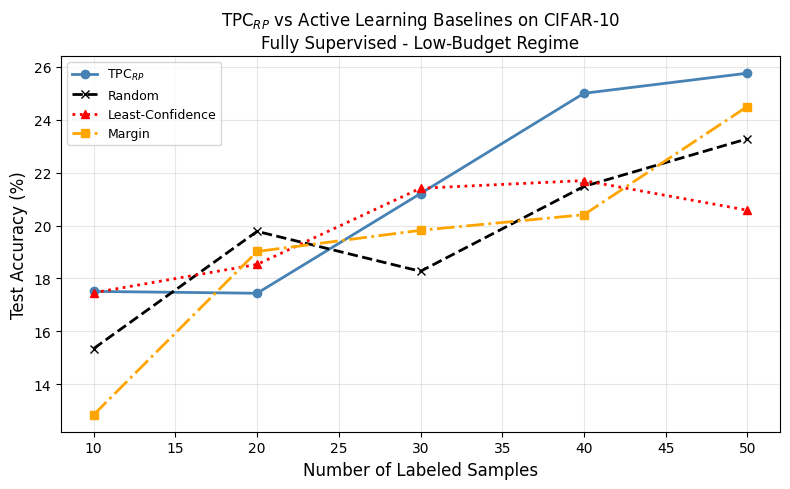

In [ ]:
# Plot TPCRP against active learning baselines
margin_counts = [r["labelled"] for r in results_margin]
margin_accs   = [r["accuracy"] for r in results_margin]

plt.figure(figsize=(8, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random")
plt.plot(uncertainty_counts, uncertainty_accs,
         marker="^", linewidth=2, linestyle=":", color="red",
         label="Least-Confidence")
plt.plot(margin_counts, margin_accs,
         marker="s", linewidth=2, linestyle="-.", color="orange",
         label="Margin")

plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Active Learning Baselines on CIFAR-10\n"
          "Fully Supervised - Low-Budget Regime", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_4baselines.png", dpi=150, bbox_inches="tight")
plt.show()

# Entropy Sampling Baseline
Selects samples with the highest predictive entropy across all classes. Provides a fuller measure of uncertainty but is still affected by poor model calibration in low-data settings.

In [ ]:
# Entropy Sampling Baseline
# Selects samples with highest predictive entropy across classes
def entropy_select_batch(
    current_model,
    unlabelled_indices,
    budget=10
):
    # Budget protection
    budget = min(budget, len(unlabelled_indices))

    current_model.eval()

    unlabelled_subset = LabeledSubset(
        unlabelled_indices,
        transform=test_transform
    )
    unlabelled_loader = DataLoader(
        unlabelled_subset,
        batch_size=256,
        shuffle=False,
        num_workers=2
    )

    all_entropies = []

    with torch.no_grad():
        for images, _ in unlabelled_loader:
            images = images.to(device)
            outputs = current_model(images)
            probs = torch.softmax(outputs, dim=1)
            # Clamp to avoid log(0)
            probs = probs.clamp(min=1e-8)
            entropy = -(probs * probs.log()).sum(dim=1)
            all_entropies.append(entropy.cpu())

    all_entropies = torch.cat(all_entropies, dim=0)

    # Highest entropy = most uncertain = query these
    _, selected_positions = torch.topk(
        all_entropies, budget, largest=True
    )

    return [unlabelled_indices[i] for i in
            selected_positions.tolist()]


def active_learning_round_entropy(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Cold start: fall back to random if no labelled data yet
    if len(labelled_indices) == 0:
        newly_selected = random.sample(
            list(unlabelled_indices),
            min(budget, len(unlabelled_indices))
        )
    else:
        # Train query model on current labelled set
        labelled_subset = LabeledSubset(
            labelled_indices,
            transform=train_transform_supervised
        )
        labelled_loader = DataLoader(
            labelled_subset,
            batch_size=eval_batch_size,
            shuffle=True,
            num_workers=2
        )
        query_model = EvalResNet18(num_classes=10).to(device)
        train_eval_model(query_model, labelled_loader,
                         epochs=eval_epochs, lr=0.025)

        # Select by entropy
        newly_selected = entropy_select_batch(
            query_model, unlabelled_indices, budget
        )

    # Update pools (same structure as other baselines)
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices
        if idx not in selected_set
    ]

    # Retrain on updated labelled set and evaluate
    labelled_subset = LabeledSubset(
        labelled_indices,
        transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

print("Entropy functions defined.")

Entropy functions defined.


In [ ]:
# Cold start: same setup as all other baselines
labelled_indices_entropy = []
unlabelled_indices_entropy = list(range(len(train_base)))
results_entropy = []

print("Initial labelled :", len(labelled_indices_entropy))
print("Initial unlabelled:", len(unlabelled_indices_entropy))

# Run entropy sampling for multiple rounds
for round_num in range(num_rounds):
    print(f"\n===== Entropy Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_entropy, unlabelled_indices_entropy, acc = \
        active_learning_round_entropy(
            labelled_indices=labelled_indices_entropy,
            unlabelled_indices=unlabelled_indices_entropy,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_entropy], minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_entropy)}")
    print(f"Unlabelled : {len(unlabelled_indices_entropy)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_entropy.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_entropy),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Entropy Round 1/5 =====
Eval Epoch 1/50, Loss: 2.4057
Eval Epoch 2/50, Loss: 2.1192
Eval Epoch 3/50, Loss: 1.8673
Eval Epoch 4/50, Loss: 1.8267
Eval Epoch 5/50, Loss: 1.5705
Eval Epoch 6/50, Loss: 1.2806
Eval Epoch 7/50, Loss: 1.0215
Eval Epoch 8/50, Loss: 0.7043
Eval Epoch 9/50, Loss: 0.4438
Eval Epoch 10/50, Loss: 0.3775
Eval Epoch 11/50, Loss: 0.1849
Eval Epoch 12/50, Loss: 0.0950
Eval Epoch 13/50, Loss: 0.0856
Eval Epoch 14/50, Loss: 0.0323
Eval Epoch 15/50, Loss: 0.0287
Eval Epoch 16/50, Loss: 0.0335
Eval Epoch 17/50, Loss: 0.0117
Eval Epoch 18/50, Loss: 0.0095
Eval Epoch 19/50, Loss: 0.0098
Eval Epoch 20/50, Loss: 0.0027
Eval Epoch 21/50, Loss: 0.0033
Eval Epoch 22/50, Loss: 0.0034
Eval Epoch 23/50, Loss: 0.0033
Eval Epoch 24/50, Loss: 0.0021
Eval Epoch 25/50, Loss: 0.0013
Eval Epoch 26/50, Loss: 0.0012
Eval Epoch 27/50, Loss: 0.0022
Eval Epoch 28/50, Loss: 0.0022
Eval Epoch 29/50, Loss: 0.0013
Eval Epoch 30/50, Loss: 0.0012
E

In [ ]:
# Compare all methods across rounds
print("Accuracy comparison: TPCRP vs Random vs Least-Confidence vs Margin vs Entropy\n")

for i in range(5):
    tpcrp_acc   = results[i]['accuracy']
    rand_acc    = results_random[i]['accuracy']
    unc_acc     = results_uncertainty[i]['accuracy']
    margin_acc  = results_margin[i]['accuracy']
    entropy_acc = results_entropy[i]['accuracy']

    print(f"Round {i+1} ({results[i]['labelled']} labels): "
          f"TPCRP = {tpcrp_acc:.2f}% | "
          f"Random = {rand_acc:.2f}% | "
          f"Least-Conf = {unc_acc:.2f}% | "
          f"Margin = {margin_acc:.2f}% | "
          f"Entropy = {entropy_acc:.2f}%")

Accuracy comparison: TPCRP vs Random vs Least-Confidence vs Margin vs Entropy

Round 1 (10 labels): TPCRP = 17.51% | Random = 15.35% | Least-Conf = 17.46% | Margin = 12.85% | Entropy = 12.91%
Round 2 (20 labels): TPCRP = 17.44% | Random = 19.78% | Least-Conf = 18.53% | Margin = 19.02% | Entropy = 14.57%
Round 3 (30 labels): TPCRP = 21.21% | Random = 18.27% | Least-Conf = 21.41% | Margin = 19.82% | Entropy = 16.07%
Round 4 (40 labels): TPCRP = 25.00% | Random = 21.48% | Least-Conf = 21.70% | Margin = 20.41% | Entropy = 17.33%
Round 5 (50 labels): TPCRP = 25.76% | Random = 23.28% | Least-Conf = 20.58% | Margin = 24.50% | Entropy = 17.92%


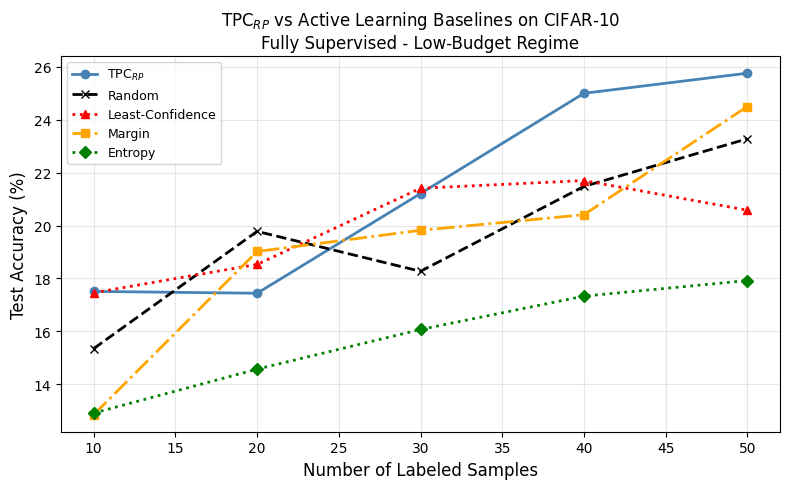

In [ ]:
# Plot TPCRP against active learning baselines
margin_counts      = [r["labelled"] for r in results_margin]
margin_accs        = [r["accuracy"] for r in results_margin]
entropy_counts     = [r["labelled"] for r in results_entropy]
entropy_accs       = [r["accuracy"] for r in results_entropy]
uncertainty_counts = [r["labelled"] for r in results_uncertainty]
uncertainty_accs   = [r["accuracy"] for r in results_uncertainty]

plt.figure(figsize=(8, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random")
plt.plot(uncertainty_counts, uncertainty_accs,
         marker="^", linewidth=2, linestyle=":", color="red",
         label="Least-Confidence")
plt.plot(margin_counts, margin_accs,
         marker="s", linewidth=2, linestyle="-.", color="orange",
         label="Margin")
plt.plot(entropy_counts, entropy_accs,
         marker="D", linewidth=2, linestyle=":", color="green",
         label="Entropy")

plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Active Learning Baselines on CIFAR-10\n"
          "Fully Supervised - Low-Budget Regime", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_all_baselines.png", dpi=150, bbox_inches="tight")
plt.show()

# Implementation Notes and Observations

TPC_RP rises from 17.51% at 10 labels to 25.76% at 50 labels, leading all methods at rounds 1, 4, and 5. The largest gainoccurs between rounds three and  four (+3.79 pp), with diminishing returns thereafter.

## Baseline Comparison

The five-way comparison supports the paper's phase-transition claim. Entropy collapses most severely, falling to 12.91% at B=10, 2.44 pp below Random and never exceeding 17.92%. Least-Confidence underperforms TPC_RP at rounds 4 and 5 despite a competitive round 3. Margin recovers to 24.50% at round 5 but remains 1.26 pp behind TPC_RP. TPC_RP leads at round 5 with 25.76% vs 23.28% for Random (+2.48 pp), 20.58% for Least-Confidence (+5.18 pp), 24.50% for Margin (+1.26 pp), and 17.92% for Entropy (+7.84 pp). At B=10, TPC_RP (17.51%) leads Random (15.35%) and matches Least-Confidence (17.46%), showing typicality-based selection is effective even at cold start. The marginal deficit at round 2 (17.44% vs 19.78% Random) reflects stochastic variance at
very small budgets.


## Why Accuracy Is Lower Than The Paper

Overall figures are lower than Hacohen et al. (2022) due to
training SimCLR for only 50 epochs rather than 500. Reduced
training yields weaker embeddings, compressing all accuracy
figures but not affecting the qualitative ordering of methods,
which matches the paper's predictions.

# Task 3: Algorithm Modification and Evaluation

### Proposed Modification and Justification



The original TPC_RP method computes typicality using Euclidean distance with a fixed neighbourhood size (K=20). Two principled modifications are proposed and evaluated through a four-variant
ablation study.


**Cosine distance (Variant A):** SimCLR produces L2-normalised embeddings on a unit hypersphere. Euclidean distance conflates direction and magnitude, whereas cosine distance measures only angular similarity, which is the quantity NT-Xent directly
optimises. This aligns typicality estimation with the inductive bias of the representation learning objective.



**Adaptive K (Variant B):** A finer-grained neighbourhood schedule is proposed: K=3 for cluster size below 10, K=5 for size 10 to 19, and K=20 otherwise. This maintains a neighbourhood-to-cluster-size ratio of approximately 30 to 50%, consistent with the paper's own min{20, cluster_size} schedule in Appendix F.1.


**Cosine distance + Adaptive K (Variant C):** Combines both modifications to evaluate whether the two changes interact additively in the density estimation step.

The following variants are evaluated through a controlled ablation study in which all variants share the same SimCLR embeddings and clustering. Only the typicality function differs, ensuring a fair comparison.

### Typicality Variants


In [ ]:
# Original (already defined as compute_typicality_scores)
# Included here for reference clarity

def compute_typicality_euclidean_fixed(cluster_embeddings, k=20):
# Original method from the paper - euclidean distance, K fixed at 20
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    k_use = min(k, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


def compute_typicality_cosine_fixed(cluster_embeddings, k=20):
    # Variant A
    # Same as original but using cosine distance instead
    # Since embeddings are normalised this might be more appropriate
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    k_use = min(k, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="cosine")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


def compute_typicality_euclidean_adaptive(cluster_embeddings, k=20):
    # Variant B
    # Euclidean distance but K changes based on cluster size
    # Small clusters get smaller K to avoid noisy estimates
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    if n < 10:
        k_adaptive = 3
    elif n < 20:
        k_adaptive = 5
    else:
        k_adaptive = min(k, 20)
    k_use = min(k_adaptive, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


def compute_typicality_cosine_adaptive(cluster_embeddings, k=20):
    # Variant C
    # Combining both changes - cosine distance and adaptive K together
    # This is the main modification I'm proposing
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    if n < 10:
        k_adaptive = 3
    elif n < 20:
        k_adaptive = 5
    else:
        k_adaptive = min(k, 20)
    k_use = min(k_adaptive, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="cosine")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


print("All four typicality functions defined.")

All four typicality functions defined.


### Running the Ablation

In [ ]:
def typiclust_select_batch_variant(
    all_embeddings, labelled_indices, unlabelled_indices,
    typicality_fn, budget=10, max_clusters=500
):
    # Same logic as original select batch but accepts any typicality function
    # Used to keep the ablation comparison fair
    labelled_indices   = list(labelled_indices)
    unlabelled_indices = list(unlabelled_indices)

    if len(unlabelled_indices) == 0:
        return []

    num_clusters = min(
        len(labelled_indices) + budget, max_clusters, len(unlabelled_indices)
    )
    unlabelled_embeddings = all_embeddings[unlabelled_indices]

    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters, random_state=SEED,
        batch_size=1024, n_init=10
    )
    unlabelled_cluster_labels = kmeans.fit_predict(unlabelled_embeddings)

    labelled_cluster_counts = np.zeros(num_clusters, dtype=int)
    if len(labelled_indices) > 0:
        labelled_embeddings = all_embeddings[labelled_indices]
        distances_to_centers = np.linalg.norm(
            labelled_embeddings[:, None, :] - kmeans.cluster_centers_[None, :, :],
            axis=2
        )
        labelled_cluster_ids = distances_to_centers.argmin(axis=1)
        for cid in labelled_cluster_ids:
            labelled_cluster_counts[cid] += 1

    cluster_to_positions = defaultdict(list)
    for pos, cid in enumerate(unlabelled_cluster_labels):
        cluster_to_positions[cid].append(pos)

    # Filter out tiny clusters - unreliable typicality below 5 points
    cluster_info = []
    for cid, positions in cluster_to_positions.items():
        if len(positions) >= 5:
            cluster_info.append({
                "cluster_id":    cid,
                "labelled_count": labelled_cluster_counts[cid],
                "size":          len(positions),
                "positions":     positions
            })

    selected_positions = []
    used_clusters      = set()

    while len(selected_positions) < budget and len(used_clusters) < len(cluster_info):
        remaining = [c for c in cluster_info if c["cluster_id"] not in used_clusters]
        if not remaining:
            break
        min_labelled = min(c["labelled_count"] for c in remaining)
        candidates   = [c for c in remaining if c["labelled_count"] == min_labelled]
        candidates.sort(key=lambda x: x["size"], reverse=True)
        chosen    = candidates[0]
        positions = chosen["positions"]
        scores    = typicality_fn(unlabelled_embeddings[positions])
        best_pos  = positions[int(np.argmax(scores))]
        selected_positions.append(best_pos)
        used_clusters.add(chosen["cluster_id"])

    return [unlabelled_indices[pos] for pos in selected_positions]


print("Generic select batch defined.")

Generic select batch defined.


In [ ]:
def active_learning_round_variant(
    all_embeddings, labelled_indices, unlabelled_indices,
    typicality_fn, budget=10, eval_epochs=50
):
    # Runs one full AL round using whichever typicality function is passed in
    newly_selected = typiclust_select_batch_variant(
        all_embeddings, labelled_indices, unlabelled_indices,
        typicality_fn=typicality_fn, budget=budget
    )
    labelled_indices   = list(labelled_indices) + newly_selected
    unlabelled_indices = [
        idx for idx in unlabelled_indices if idx not in set(newly_selected)
    ]
    subset = LabeledSubset(labelled_indices, transform=train_transform_supervised)
    loader = DataLoader(subset, batch_size=128, shuffle=True, num_workers=2)
    model  = EvalResNet18(num_classes=10).to(device)
    train_eval_model(model, loader, epochs=eval_epochs, lr=0.025)
    acc = evaluate_model(model, test_loader)
    return labelled_indices, unlabelled_indices, acc


print("Generic AL round defined.")

Generic AL round defined.


In [ ]:
# Variant A - testing cosine distance only
labelled_A   = []
unlabelled_A = list(range(len(train_base)))
results_A    = []

print("=" * 55)
print("Variant A: Cosine distance, fixed K=20")
print("=" * 55)

for round_num in range(5):
    print(f"\n--- Variant A Round {round_num + 1}/5 ---")
    labelled_A, unlabelled_A, acc = active_learning_round_variant(
        all_train_embeddings, labelled_A, unlabelled_A,
        typicality_fn=compute_typicality_cosine_fixed,
        budget=10, eval_epochs=50
    )
    class_counts = np.bincount(all_train_labels[labelled_A], minlength=10)
    print(f"Labelled: {len(labelled_A)} | Accuracy: {acc:.2f}%")
    print(f"Class dist: {class_counts.tolist()}")
    results_A.append({
        "round": round_num + 1,
        "labelled": len(labelled_A),
        "accuracy": acc
    })

Variant A: Cosine distance, fixed K=20

--- Variant A Round 1/5 ---
Eval Epoch 1/50, Loss: 2.5069
Eval Epoch 2/50, Loss: 1.7665
Eval Epoch 3/50, Loss: 1.6238
Eval Epoch 4/50, Loss: 1.5789
Eval Epoch 5/50, Loss: 1.4311
Eval Epoch 6/50, Loss: 0.8162
Eval Epoch 7/50, Loss: 0.7408
Eval Epoch 8/50, Loss: 0.6107
Eval Epoch 9/50, Loss: 0.3619
Eval Epoch 10/50, Loss: 0.3820
Eval Epoch 11/50, Loss: 0.3458
Eval Epoch 12/50, Loss: 0.1363
Eval Epoch 13/50, Loss: 0.1147
Eval Epoch 14/50, Loss: 0.2425
Eval Epoch 15/50, Loss: 0.6476
Eval Epoch 16/50, Loss: 0.6039
Eval Epoch 17/50, Loss: 0.0393
Eval Epoch 18/50, Loss: 0.0813
Eval Epoch 19/50, Loss: 0.0277
Eval Epoch 20/50, Loss: 0.0315
Eval Epoch 21/50, Loss: 0.0132
Eval Epoch 22/50, Loss: 0.0330
Eval Epoch 23/50, Loss: 0.0217
Eval Epoch 24/50, Loss: 0.0330
Eval Epoch 25/50, Loss: 0.0088
Eval Epoch 26/50, Loss: 0.0055
Eval Epoch 27/50, Loss: 0.0048
Eval Epoch 28/50, Loss: 0.0036
Eval Epoch 29/50, Loss: 0.0383
Eval Epoch 30/50, Loss: 0.0055
Eval Epoch 

In [ ]:
# Variant B - testing adaptive K only
labelled_B   = []
unlabelled_B = list(range(len(train_base)))
results_B    = []

print("=" * 55)
print("Variant B: Euclidean distance, adaptive K")
print("=" * 55)

for round_num in range(5):
    print(f"\n--- Variant B Round {round_num + 1}/5 ---")
    labelled_B, unlabelled_B, acc = active_learning_round_variant(
        all_train_embeddings, labelled_B, unlabelled_B,
        typicality_fn=compute_typicality_euclidean_adaptive,
        budget=10, eval_epochs=50
    )
    class_counts = np.bincount(all_train_labels[labelled_B], minlength=10)
    print(f"Labelled: {len(labelled_B)} | Accuracy: {acc:.2f}%")
    print(f"Class dist: {class_counts.tolist()}")
    results_B.append({
        "round": round_num + 1,
        "labelled": len(labelled_B),
        "accuracy": acc
    })

Variant B: Euclidean distance, adaptive K

--- Variant B Round 1/5 ---
Eval Epoch 1/50, Loss: 2.4331
Eval Epoch 2/50, Loss: 1.8156
Eval Epoch 3/50, Loss: 1.9898
Eval Epoch 4/50, Loss: 1.4785
Eval Epoch 5/50, Loss: 1.3442
Eval Epoch 6/50, Loss: 1.1530
Eval Epoch 7/50, Loss: 0.9193
Eval Epoch 8/50, Loss: 0.6388
Eval Epoch 9/50, Loss: 0.5692
Eval Epoch 10/50, Loss: 0.4032
Eval Epoch 11/50, Loss: 0.2304
Eval Epoch 12/50, Loss: 0.1767
Eval Epoch 13/50, Loss: 0.0679
Eval Epoch 14/50, Loss: 0.0369
Eval Epoch 15/50, Loss: 0.0193
Eval Epoch 16/50, Loss: 0.0183
Eval Epoch 17/50, Loss: 0.0088
Eval Epoch 18/50, Loss: 0.0073
Eval Epoch 19/50, Loss: 0.0080
Eval Epoch 20/50, Loss: 0.0028
Eval Epoch 21/50, Loss: 0.0088
Eval Epoch 22/50, Loss: 0.0025
Eval Epoch 23/50, Loss: 0.0030
Eval Epoch 24/50, Loss: 0.0021
Eval Epoch 25/50, Loss: 0.0019
Eval Epoch 26/50, Loss: 0.0011
Eval Epoch 27/50, Loss: 0.0034
Eval Epoch 28/50, Loss: 0.0015
Eval Epoch 29/50, Loss: 0.0014
Eval Epoch 30/50, Loss: 0.0016
Eval Epo

In [ ]:
# Variant C - both changes combined
labelled_C   = []
unlabelled_C = list(range(len(train_base)))
results_C    = []

print("=" * 55)
print("Variant C: Cosine distance + adaptive K (combined)")
print("=" * 55)

for round_num in range(5):
    print(f"\n--- Variant C Round {round_num + 1}/5 ---")
    labelled_C, unlabelled_C, acc = active_learning_round_variant(
        all_train_embeddings, labelled_C, unlabelled_C,
        typicality_fn=compute_typicality_cosine_adaptive,
        budget=10, eval_epochs=50
    )
    class_counts = np.bincount(all_train_labels[labelled_C], minlength=10)
    print(f"Labelled: {len(labelled_C)} | Accuracy: {acc:.2f}%")
    print(f"Class dist: {class_counts.tolist()}")
    results_C.append({
        "round": round_num + 1,
        "labelled": len(labelled_C),
        "accuracy": acc
    })

Variant C: Cosine distance + adaptive K (combined)

--- Variant C Round 1/5 ---
Eval Epoch 1/50, Loss: 2.1950
Eval Epoch 2/50, Loss: 2.0396
Eval Epoch 3/50, Loss: 2.5398
Eval Epoch 4/50, Loss: 2.2512
Eval Epoch 5/50, Loss: 2.2769
Eval Epoch 6/50, Loss: 1.7256
Eval Epoch 7/50, Loss: 1.6195
Eval Epoch 8/50, Loss: 1.1159
Eval Epoch 9/50, Loss: 0.4852
Eval Epoch 10/50, Loss: 0.3371
Eval Epoch 11/50, Loss: 0.2344
Eval Epoch 12/50, Loss: 0.1688
Eval Epoch 13/50, Loss: 0.0921
Eval Epoch 14/50, Loss: 0.0734
Eval Epoch 15/50, Loss: 0.0299
Eval Epoch 16/50, Loss: 0.0666
Eval Epoch 17/50, Loss: 0.0316
Eval Epoch 18/50, Loss: 0.0441
Eval Epoch 19/50, Loss: 0.0110
Eval Epoch 20/50, Loss: 0.0070
Eval Epoch 21/50, Loss: 0.0111
Eval Epoch 22/50, Loss: 0.0042
Eval Epoch 23/50, Loss: 0.0079
Eval Epoch 24/50, Loss: 0.0037
Eval Epoch 25/50, Loss: 0.0063
Eval Epoch 26/50, Loss: 0.0050
Eval Epoch 27/50, Loss: 0.0025
Eval Epoch 28/50, Loss: 0.0017
Eval Epoch 29/50, Loss: 0.0022
Eval Epoch 30/50, Loss: 0.0036

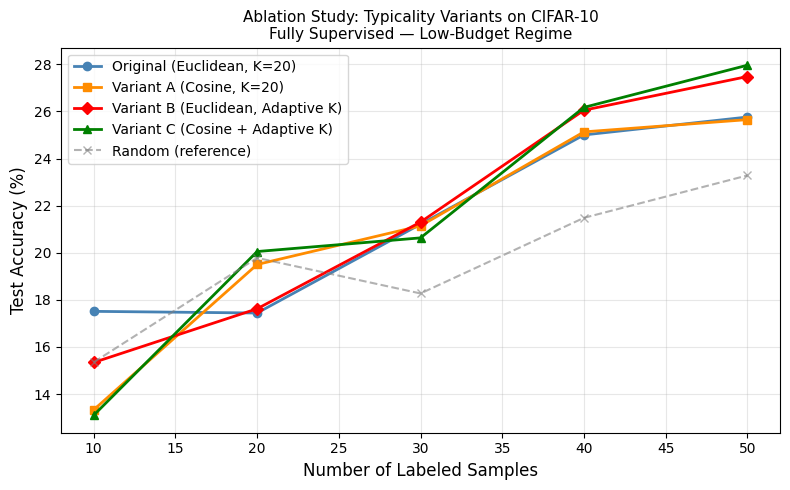

In [ ]:
# Plot all four variants together for comparison
original_labeled = [r["labelled"] for r in results]
original_acc = [r["accuracy"] for r in results]
varA_labeled = [r["labelled"] for r in results_A]
varA_acc = [r["accuracy"] for r in results_A]
varB_labeled = [r["labelled"] for r in results_B]
varB_acc = [r["accuracy"] for r in results_B]
varC_labeled = [r["labelled"] for r in results_C]
varC_acc = [r["accuracy"] for r in results_C]

plt.figure(figsize=(8, 5))
plt.plot(original_labeled, original_acc, marker="o", linewidth=2, color="steelblue",  label="Original (Euclidean, K=20)")
plt.plot(varA_labeled, varA_acc, marker="s", linewidth=2, color="darkorange", label="Variant A (Cosine, K=20)")
plt.plot(varB_labeled, varB_acc, marker="D", linewidth=2, color="red", label="Variant B (Euclidean, Adaptive K)")
plt.plot(varC_labeled, varC_acc, marker="^", linewidth=2, color="green", label="Variant C (Cosine + Adaptive K)")
plt.plot(random_counts, random_accs,marker="x", linewidth=1.5, linestyle="--", color="grey",alpha=0.6, label="Random (reference)")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Ablation Study: Typicality Variants on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Print accuracy for all variants per round for easy comparison
print("Accuracy (%) across active learning rounds:\n")
for i in range(5):
    orig = results[i]['accuracy']
    a = results_A[i]['accuracy']
    b = results_B[i]['accuracy']
    c = results_C[i]['accuracy']
    print(f"Round {i+1}: "
          f"Original = {orig:.2f}% | "
          f"Cosine (k=20) = {a:.2f}% | "
          f"Euclidean (adaptive) = {b:.2f}% | "
          f"Cosine (adaptive) = {c:.2f}%")

print("\nDone.")

Accuracy (%) across active learning rounds:

Round 1: Original = 17.51% | Cosine (k=20) = 13.33% | Euclidean (adaptive) = 15.34% | Cosine (adaptive) = 13.10%
Round 2: Original = 17.44% | Cosine (k=20) = 19.50% | Euclidean (adaptive) = 17.62% | Cosine (adaptive) = 20.05%
Round 3: Original = 21.21% | Cosine (k=20) = 21.14% | Euclidean (adaptive) = 21.30% | Cosine (adaptive) = 20.63%
Round 4: Original = 25.00% | Cosine (k=20) = 25.13% | Euclidean (adaptive) = 26.05% | Cosine (adaptive) = 26.17%
Round 5: Original = 25.76% | Cosine (k=20) = 25.65% | Euclidean (adaptive) = 27.48% | Cosine (adaptive) = 27.96%

Done.


# Conclusion

TPCRP rises from 17.51% at 10 labels to 25.76% at 50 labels,
leading all methods at rounds one, four, and five. Entropy
collapses to 12.91% at round one and never exceeds 17.92%,
directly confirming the paper's cold start hypothesis that
uncertainty based methods produce misleading confidence scores
when the model is undertrained. Least Confidence and Margin
similarly underperform TPCRP in later rounds despite partial
recovery as the labelled set grows.

The ablation study shows Variant C achieves the strongest
final accuracy, followed closely by Variant B, with both
outperforming the original at rounds four and five. Variant A
performs comparably to the original, suggesting the geometric
advantage of cosine distance requires fully trained embeddings
to have its full effect. All four variants outperform all
uncertainty based baselines at round five, confirming
typicality based querying provides genuine value independent
of the specific distance metric used.

The key limitations of this study are the use of 50 rather
than 500 SimCLR epochs, which yields weaker embeddings and
compresses all accuracy figures, and the use of a single
random seed, which prevents formal significance testing.
Results should therefore be interpreted as indicative trends
rather than statistically confirmed effects.

## Code Repository

The full implementation is available at the following GitHub
repository: [GitHub Repository Link](https://github.com/llayan-1/typiclust-cw2.git)